# Programming in Python II - Final Coding Project

Author: Denys Siianchuk

Student ID: K12456319

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import pandas as pd

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
seed = 1
np.random.seed(seed)

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

In [2]:
# checking successful setup
print(f"Using device: {device}")

Using device: cuda


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Set working directory to the project folder
os.chdir("/home/convidium/Desktop/python_2/cnn_image_classifier")  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/convidium/Desktop/python_2/cnn_image_classifier


In [ ]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

## Data Handling and Pre-Processing

In [5]:
def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:
    img_classes = [d for d in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, d))]

    label_dict = {cls_name: idx for idx, cls_name in enumerate(img_classes)}

    dataset = []

    for img_class_name in img_classes:
        img_class_folder = os.path.join(data_folder, img_class_name)

        for file_name in os.listdir(img_class_folder):
            folder_path = f"{os.path.basename(data_folder)}/{img_class_name}"

            dataset.append({
                'folder': folder_path,
                'file_name': file_name,
                'label': label_dict[img_class_name]
            })

    df = pd.DataFrame(dataset)
    return df, label_dict
    

dataset, label_dict = preprocess("data/train_data")

In [6]:
# checking successful dataframe loading

# uncomment after preprocessing the dataset and adapt the variable name
print(f"Length of dataset: {len(dataset)}") # Should be 10000

Length of dataset: 10000


In [16]:
# your code goes here (splitting train/validation datasets)
train_dataset, val_dataset = train_test_split(
    dataset, 
    test_size=0.2, 
    stratify=dataset['label'], 
    random_state=seed
)

train_dataset["label"].value_counts()

label
7    800
9    800
1    800
6    800
8    800
3    800
0    800
2    800
4    800
5    800
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

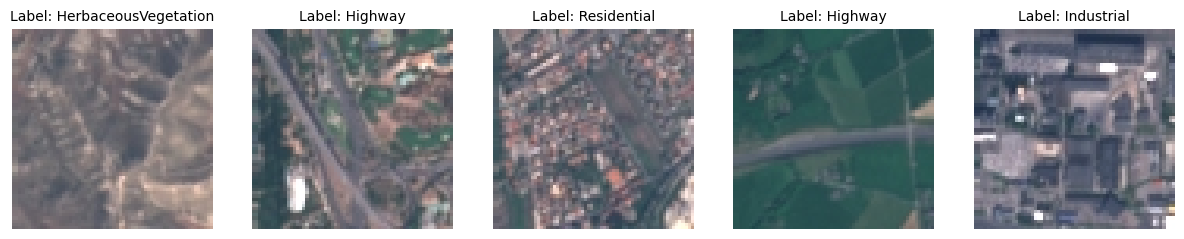

In [8]:
# your code goes here (show_samples)
def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:
    sample_set = df.sample(num_samples, random_state=seed)

    fig, ax = plt.subplots(1, num_samples, figsize=(15, 6))

    sample_paths = sample_set["folder"].to_numpy()
    sample_names = sample_set["file_name"].to_numpy()

    sample_full_paths = "data/" + sample_paths + "/" + sample_names
    for i in range(len(sample_full_paths)):
        read_image_data = plt.imread(sample_full_paths[i])
        ax[i].imshow(read_image_data)
        ax[i].axis(False)
        ax[i].set_title(f"Label: {sample_names[i].split("_")[0]}", fontsize=10)
    fig.savefig("assets/plots/random_samples.png")
    return

show_samples(dataset, 5)

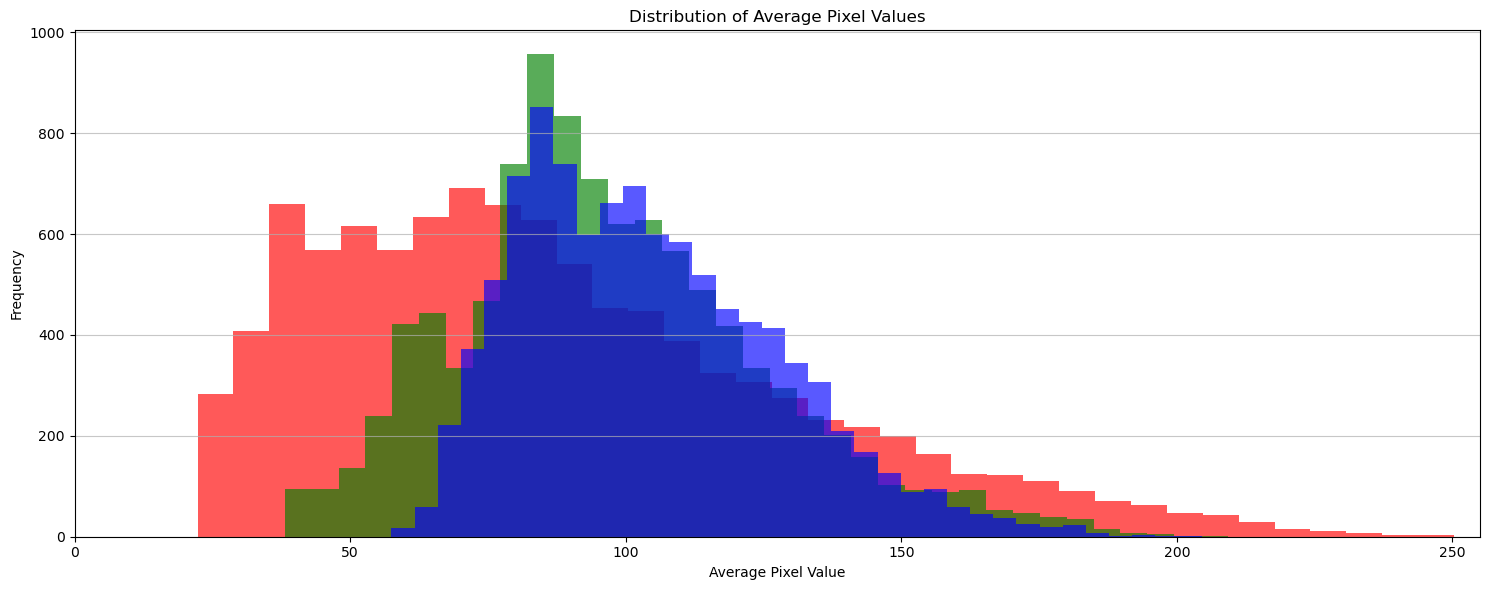

In [9]:
# your code goes here (average_pixel_plot)
def average_pixel_plot(df: pd.DataFrame) -> None:
    mean_red = []
    mean_green = []
    mean_blue = []

    for index, sample in df.iterrows():
        sample_full_path = f"data/{sample['folder']}/{sample['file_name']}"
        img = plt.imread(sample_full_path)
    
        channels_mean = img.mean(axis=(0, 1))
    
        mean_red.append(channels_mean[0])
        mean_green.append(channels_mean[1])
        mean_blue.append(channels_mean[2])



    fig, ax = plt.subplots(figsize=(15, 6))

    ax.hist(mean_red, bins=35, alpha=0.65, color='red', label='Red Channel')
    ax.hist(mean_green, bins=35, alpha=0.65, color='green', label='Green Channel')
    ax.hist(mean_blue, bins=35, alpha=0.65, color='blue', label='Blue Channel')

    ax.set_title("Distribution of Average Pixel Values")
    ax.set_xlabel("Average Pixel Value")
    ax.set_ylabel("Frequency")

    ax.grid(axis='y', linestyle='-', alpha=0.7)
    ax.set_xlim(0, 255)
    fig.tight_layout()
    os.makedirs("assets/plots", exist_ok=True)
    fig.savefig("assets/plots/average_pixel_distribution.png")
    plt.show()
    
    return

average_pixel_plot(dataset)

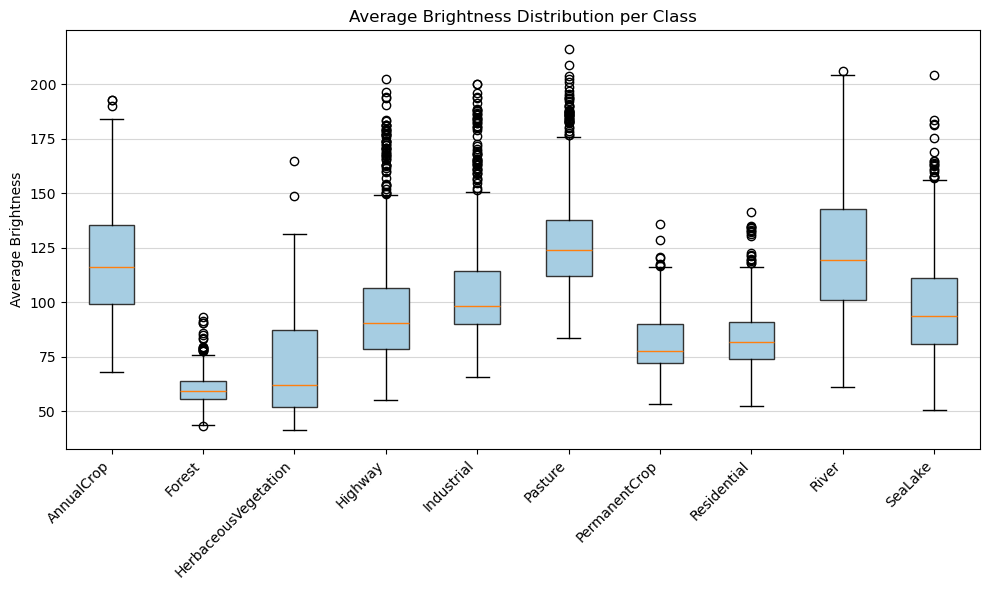

In [10]:
# your code goes here (average_brightness_per_class)
def average_brightness_per_class(df: pd.DataFrame) -> None:
    df_working = df.copy()

    classes = sorted(label_dict.keys())
    data_to_plot = []

    for name, group in df_working.groupby('label'):
        group_brightness_list = []
    
        for index, sample in group.iterrows():
            sample_full_path = f"data/{sample['folder']}/{sample['file_name']}"
            img = plt.imread(sample_full_path)
            img_brightness = img.mean()

            group_brightness_list.append(img_brightness)

        data_to_plot.append(np.array(group_brightness_list))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.boxplot(
        data_to_plot, 
        labels=classes, 
        patch_artist=True,
        boxprops=dict(facecolor='#a6cde2', color='#333333', linewidth=1)
    )
    
    ax.set_title("Average Brightness Distribution per Class")
    ax.set_ylabel("Average Brightness")
    ax.grid(axis='y', linestyle='-', alpha=0.5)
    
    ax.set_xticklabels(classes, rotation=45, ha='right')
    
    fig.tight_layout()
    
    os.makedirs("assets/plots", exist_ok=True)
    fig.savefig("assets/plots/average_brightness.png")
    
    plt.show()

average_brightness_per_class(dataset)

## CNN Implementation and Training

### Dataset class

In [11]:
# your code goes here
import torch
from torch.utils.data import Dataset
import torchvision.io
import torchvision.transforms as transforms

class SatelliteImageDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        sample = self.df.iloc[index]
        
        img_path = f"data/{sample['folder']}/{sample['file_name']}"
        image = torchvision.io.read_image(img_path)
        image = image.float() / 255.0
        
        label = int(sample['label'])
        
        if self.transform is not None:
            image = self.transform(image)
            
        return image, label
    

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomErasing(p=0.2),
    transforms.RandomAutocontrast(p=0.2),
    transforms.RandomGrayscale(p=0.15),
])

val_transform = None

### Data Loaders

In [17]:
# your code goes here

from torch.utils.data import DataLoader
num_workers = min(4, os.cpu_count())

train_dataset = SatelliteImageDataset(train_dataset, transform=train_transform)
val_dataset = SatelliteImageDataset(val_dataset, transform=val_transform)

train_dataloader = DataLoader(
    train_dataset, 
    batch_size=128, 
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset, 
    batch_size=128, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

### Model Architecture

In [18]:
import torch.nn as nn

class SatelliteImgCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.part_block_1 = nn.Sequential(
            # Input: 64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Output: 32x32
        )

        self.part_block_2 = nn.Sequential(
            # Input: 32x32
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU() # Output: 32x32
        )

        self.res_block = nn.Sequential(
            # Input: 32x32
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128) # Output: 32x32
        )
        self.res_relu = nn.ReLU()

        self.part_block_3 = nn.Sequential(
            # Input: 16x16
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Output: 8x8
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.35),
            nn.Linear(in_features=128, out_features=10)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.part_block_1(x)
        x = self.part_block_2(x)
        block_2 = x

        res_block = self.res_block(x)
        res_block += block_2
        x = self.res_relu(res_block)

        x = self.part_block_3(x)
        x = self.global_pool(x)

        return self.classifier(x)

### Training Loop

In [27]:
# your code goes here
import torch.optim as optim

model = SatelliteImgCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0008, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=175, eta_min=1e-6)

num_epochs = 175
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_accuracy = 0.0

os.makedirs("assets/weights", exist_ok=True)

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_dataloader:
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(features)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_dataloader:
            features = features.to(device)
            labels = labels.to(device).long()
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, dim=1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_dataloader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], \nTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy*100:.2f}%, \nVal Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy*100:.2f}% \n")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "assets/weights/best_model.pth")
        print(f"Saved a model with the best Val Accuracy: {val_accuracy*100:.2f}%")

Epoch [1/175], 
Train Loss: 1.4843, Train Accuracy: 47.35%, 
Val Loss: 1.5355, Val Accuracy: 47.75% 

Saved a model with the best Val Accuracy: 47.75%
Epoch [2/175], 
Train Loss: 1.1182, Train Accuracy: 60.29%, 
Val Loss: 1.1497, Val Accuracy: 58.30% 

Saved a model with the best Val Accuracy: 58.30%
Epoch [3/175], 
Train Loss: 0.9867, Train Accuracy: 64.95%, 
Val Loss: 1.5671, Val Accuracy: 50.10% 

Epoch [4/175], 
Train Loss: 0.9442, Train Accuracy: 66.67%, 
Val Loss: 0.9421, Val Accuracy: 63.55% 

Saved a model with the best Val Accuracy: 63.55%
Epoch [5/175], 
Train Loss: 0.8690, Train Accuracy: 68.85%, 
Val Loss: 0.8900, Val Accuracy: 67.85% 

Saved a model with the best Val Accuracy: 67.85%
Epoch [6/175], 
Train Loss: 0.7968, Train Accuracy: 71.28%, 
Val Loss: 0.6741, Val Accuracy: 74.95% 

Saved a model with the best Val Accuracy: 74.95%
Epoch [7/175], 
Train Loss: 0.7730, Train Accuracy: 72.67%, 
Val Loss: 0.8625, Val Accuracy: 71.50% 

Epoch [8/175], 
Train Loss: 0.7477, Train

## Model Evaluation

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'Accuracy improvement over time')

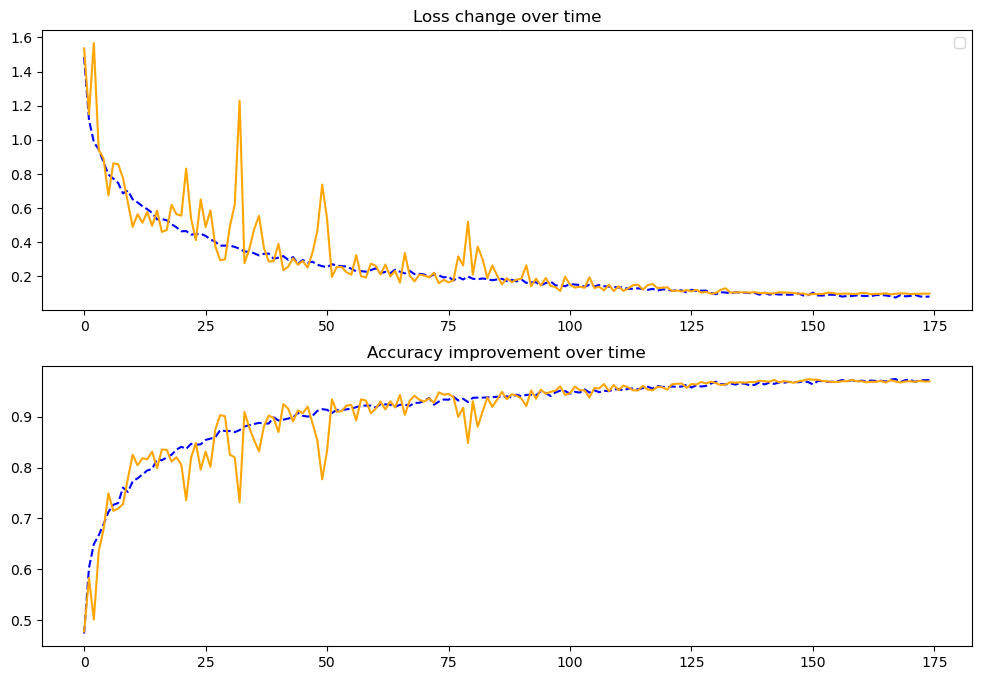

In [28]:
# your code goes here (plot_training_curves)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(train_losses, linestyle="--", color="b")
ax1.plot(val_losses, color="orange")

ax1.set_title("Loss change over time")
ax1.legend()

ax2.plot(train_accuracies, linestyle="--", color="b")
ax2.plot(val_accuracies, color="orange")

ax2.set_title("Accuracy improvement over time")


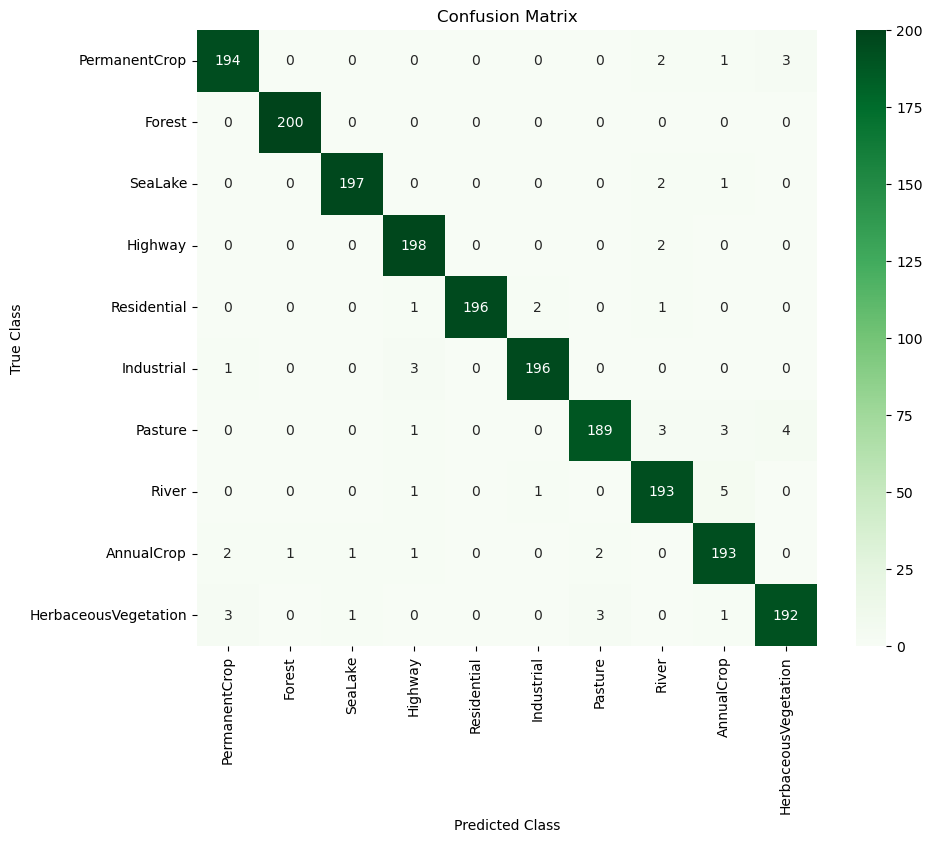

In [29]:
# your code goes here (plot_confusion_matrix)
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.load_state_dict(torch.load("assets/weights/best_model.pth"))
model.eval()
predictions = []
true_labels = []
    
with torch.no_grad():
    for features, labels in val_dataloader:
        features = features.to(device)
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)
            
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.numpy())
            
index_to_class_name = {}

for class_name, class_index in label_dict.items():
    index_to_class_name[class_index] = class_name

class_names = []
for i in range(10):
    name = index_to_class_name[i]
    class_names.append(name)
    
val_confusion_matrix = confusion_matrix(true_labels, predictions)
    
plt.figure(figsize=(10, 8))
sns.heatmap(val_confusion_matrix, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
    
os.makedirs("assets/plots", exist_ok=True)
plt.savefig("assets/plots/confusion_matrix.png")
plt.show()

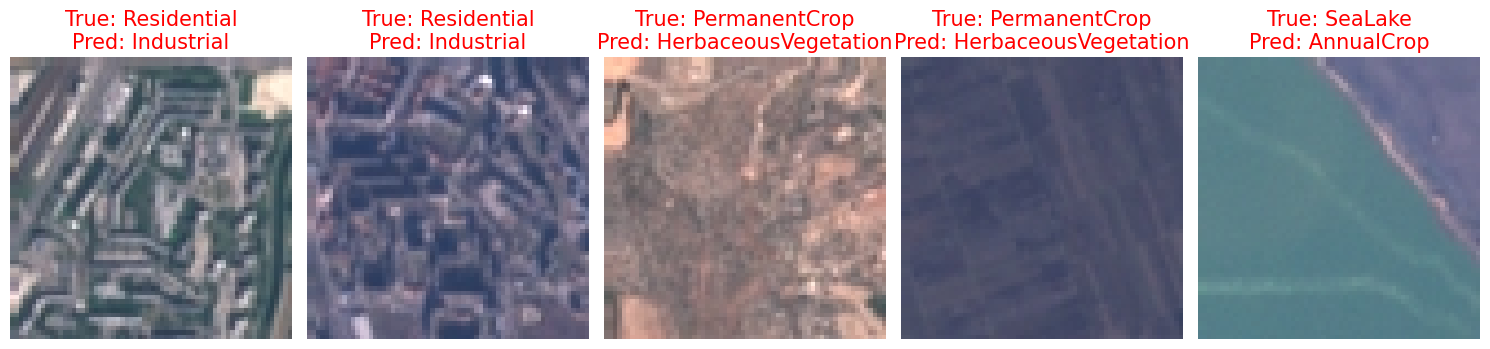

In [30]:
# your code goes here (plot_misclassified_samples)
model.eval()
num_samples = 5
index_to_name = {}
for name, idx in label_dict.items():
    index_to_name[idx] = name

wrong_images = []
wrong_trues = []
wrong_preds = []

with torch.no_grad():
    for images, labels in val_dataloader:
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        
        preds = torch.argmax(outputs, dim=1)
        preds_cpu = preds.cpu()
        
        for i in range(len(labels)):
            true_val = labels[i].item()
            pred_val = preds_cpu[i].item()
            
            if true_val != pred_val:
                wrong_images.append(images[i])
                wrong_trues.append(true_val)
                wrong_preds.append(pred_val)
                
        if len(wrong_images) >= num_samples:
            break

fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))

for i in range(num_samples):
    current_img = wrong_images[i].permute(1, 2, 0).numpy()
    
    axes[i].imshow(current_img)
    axes[i].axis('off')
    
    true_class_name = index_to_name[wrong_trues[i]]
    pred_class_name = index_to_name[wrong_preds[i]]
    
    title_text = f"True: {true_class_name}\nPred: {pred_class_name}"
    axes[i].set_title(title_text, fontsize=15, color='red')

plt.tight_layout()
plt.savefig("assets/plots/misclassified_samples.png")
plt.show()

### Test Set

In [42]:
# your code goes here (preprocess_test_data)
def preprocess_test_data(data_folder: str) -> pd.DataFrame:
    if not os.path.exists(data_folder):
        raise FileNotFoundError(f"Folder {data_folder} not found!")
        
    all_files = os.listdir(data_folder)
    test_files = [f for f in all_files]
    
    folder_name = os.path.basename(os.path.normpath(data_folder))
    
    test_df = pd.DataFrame({
        'folder': [folder_name] * len(test_files),
        'file_name': test_files
    })
    
    return test_df

test_data_path = "data/test_data"
test_df = preprocess_test_data(test_data_path)

print(f"Found test images: {len(test_df)}")
print(test_df.head(), "\n")

Found test images: 1980
      folder file_name
0  test_data  4665.jpg
1  test_data  7946.jpg
2  test_data  4221.jpg
3  test_data  1405.jpg
4  test_data  1133.jpg 



In [44]:
# your code goes here (create dataset and dataloader)
from torch.utils.data import DataLoader

class SatelliteTestDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df
        self.base_dir = base_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.base_dir, row['folder'], row['file_name'])
        
        image = torchvision.io.read_image(img_path).float() / 255.0
        
        if self.transform:
            image = self.transform(image)
            
        return image, -1

test_dataset = SatelliteTestDataset(test_df, "data", transform=val_transform)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=num_workers)

print(f"Test DataLoader successfully created with {len(test_dataloader)} batches.")

Test DataLoader successfully created with 16 batches.


In [45]:
# your code goes here (evaluate model on test set)
model.load_state_dict(torch.load("assets/weights/best_model.pth"))
model.to(device)
model.eval()

index_to_class_name = {index: name for name, index in label_dict.items()}

test_predictions = []
file_names = list(test_df['file_name'])

with torch.no_grad():
    for images, _ in test_dataloader:
        images = images.to(device)
        
        outputs = model(images)
        pred_indices = torch.argmax(outputs, dim=1).cpu().numpy()
        
        batch_classes = [index_to_class_name[idx] for idx in pred_indices]
        test_predictions.extend(batch_classes)

print(f"Successfully evaluated model on {len(test_predictions)} test samples.")

Successfully evaluated model on 1980 test samples.


In [ ]:
# your code goes here (create submission csv file for challenge server)
submission_df = pd.DataFrame({
    'file_name': file_names,
    'predicted_class': test_predictions
})

submission_df.to_csv("submission.csv", index=False, header=False)

print("--- Generation Finished! ---")
print('File "submission.csv" has been successfully created in the root folder.')
print("First 5 rows from the file:")
print(submission_df.head())